In [98]:
import datajoint as dj
import datetime
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import GridSearchCV

In [2]:
df = pd.read_pickle(f"../datasets/Clustering.pkl")
df.head()

,experimenter,date,exp_num,raw_id,field,region,cond1,cond2,roi_id,preprocess_id_x_gChirp,...,os_index_movingbar,os_pvalue_movingbar,pref_or_movingbar,on_off_movingbar,d_qi_movingbar,dir_component_movingbar,time_component_movingbar,time_component_dt_movingbar,surrogate_v_movingbar,surrogate_dsi_movingbar
0,Salomon,2025-09-08,2,1,XY1,RR,v,C1,1,1,...,0.276144,0.29,1.251740,-0.30,0.424169,"[0.2692992, 0.21163529, 1.0, 0.0, 0.5561289, 0...","[0.26338604, -0.32434568, 0.50420314, 0.173609...",0.128,"[0.40229368, 0.0, 1.0, 0.22974569, 0.2547209, ...",0.099733
1,Salomon,2025-09-08,2,1,XY1,RR,v,C1,2,1,...,0.154824,0.58,2.867670,-0.06,0.573542,"[0.57404375, 0.5936899, 0.0, 0.09891763, 0.595...","[0.23134468, 0.12591584, -0.19623627, 0.122565...",0.128,"[0.71617424, 0.42367765, 0.0, 0.07766017, 0.33...",0.477601
2,Salomon,2025-09-08,2,1,XY1,RR,v,C1,3,1,...,0.483200,0.02,0.861053,-0.24,0.425207,"[0.35994393, 0.4662192, 0.58913016, 0.14168158...","[0.47586474, -0.5384664, -0.35983962, -0.44003...",0.128,"[0.3359132, 0.3226042, 0.47080025, 0.0, 0.3162...",0.222633
3,Salomon,2025-09-08,2,1,XY1,RR,v,C1,4,1,...,0.158540,0.43,0.351112,0.12,0.508752,"[0.05255287, 1.0, 0.0, 0.9599831, 0.82622796, ...","[-0.6013447, 0.066103116, 0.07772926, 0.050788...",0.128,"[0.35936928, 0.6933557, 0.0, 1.0, 0.77427435, ...",0.087994
4,Salomon,2025-09-08,2,1,XY1,RR,v,C1,5,1,...,0.059757,0.77,2.606700,-0.04,0.386349,"[0.09850365, 0.63157904, 0.0, 0.045831554, 0.4...","[0.06198706, 0.373452, 0.6631308, -0.64670223,...",0.128,"[0.2739429, 0.9214205, 0.08431966, 0.12541033,...",0.238921


In [3]:
df_c1 = df[df["cond2"] == "C1"]
df_c1.head()

,experimenter,date,exp_num,raw_id,field,region,cond1,cond2,roi_id,preprocess_id_x_gChirp,...,os_index_movingbar,os_pvalue_movingbar,pref_or_movingbar,on_off_movingbar,d_qi_movingbar,dir_component_movingbar,time_component_movingbar,time_component_dt_movingbar,surrogate_v_movingbar,surrogate_dsi_movingbar
0,Salomon,2025-09-08,2,1,XY1,RR,v,C1,1,1,...,0.276144,0.29,1.251740,-0.30,0.424169,"[0.2692992, 0.21163529, 1.0, 0.0, 0.5561289, 0...","[0.26338604, -0.32434568, 0.50420314, 0.173609...",0.128,"[0.40229368, 0.0, 1.0, 0.22974569, 0.2547209, ...",0.099733
1,Salomon,2025-09-08,2,1,XY1,RR,v,C1,2,1,...,0.154824,0.58,2.867670,-0.06,0.573542,"[0.57404375, 0.5936899, 0.0, 0.09891763, 0.595...","[0.23134468, 0.12591584, -0.19623627, 0.122565...",0.128,"[0.71617424, 0.42367765, 0.0, 0.07766017, 0.33...",0.477601
2,Salomon,2025-09-08,2,1,XY1,RR,v,C1,3,1,...,0.483200,0.02,0.861053,-0.24,0.425207,"[0.35994393, 0.4662192, 0.58913016, 0.14168158...","[0.47586474, -0.5384664, -0.35983962, -0.44003...",0.128,"[0.3359132, 0.3226042, 0.47080025, 0.0, 0.3162...",0.222633
3,Salomon,2025-09-08,2,1,XY1,RR,v,C1,4,1,...,0.158540,0.43,0.351112,0.12,0.508752,"[0.05255287, 1.0, 0.0, 0.9599831, 0.82622796, ...","[-0.6013447, 0.066103116, 0.07772926, 0.050788...",0.128,"[0.35936928, 0.6933557, 0.0, 1.0, 0.77427435, ...",0.087994
4,Salomon,2025-09-08,2,1,XY1,RR,v,C1,5,1,...,0.059757,0.77,2.606700,-0.04,0.386349,"[0.09850365, 0.63157904, 0.0, 0.045831554, 0.4...","[0.06198706, 0.373452, 0.6631308, -0.64670223,...",0.128,"[0.2739429, 0.9214205, 0.08431966, 0.12541033,...",0.238921


In [4]:
dates = df_c1["date"].unique()

for date in dates:

    df_date = df_c1[df_c1["date"] == date]
    fields = df_date["field"].unique()

    for field in fields:

        df_field = df_date[df_date["field"] == field]
        cond2 = df_field["cond2"].unique()

        df_field_filtered = df_field[df_field["qidx_gChirp"] > 0.35]

        print(f"{date}; {field}: Filtered: {len(df_field_filtered)}, All: {len(df_field)}, In %: {np.round(len(df_field_filtered)/len(df_field)*100, 0)}")

2025-09-08; XY1: Filtered: 6, All: 93, In %: 6.0
2025-09-08; XY2: Filtered: 61, All: 187, In %: 33.0
2025-09-08; XY3: Filtered: 84, All: 134, In %: 63.0
2025-09-08; XY4: Filtered: 8, All: 160, In %: 5.0
2025-09-08; XY6: Filtered: 28, All: 149, In %: 19.0
2025-09-08; XY7: Filtered: 246, All: 249, In %: 99.0
2025-09-08; XY8: Filtered: 221, All: 258, In %: 86.0
2025-10-23; XY7: Filtered: 147, All: 177, In %: 83.0
2025-10-23; XY8: Filtered: 13, All: 183, In %: 7.0
2025-10-23; XY1: Filtered: 1, All: 167, In %: 1.0
2025-10-23; XY2: Filtered: 71, All: 163, In %: 44.0
2025-10-23; XY3: Filtered: 25, All: 113, In %: 22.0
2025-10-23; XY4: Filtered: 189, All: 189, In %: 100.0
2025-10-23; XY5: Filtered: 177, All: 182, In %: 97.0
2025-10-23; XY6: Filtered: 154, All: 166, In %: 93.0
2025-11-19; XY4: Filtered: 187, All: 187, In %: 100.0
2025-11-19; XY5: Filtered: 0, All: 187, In %: 0.0


In [5]:
# Quality threshold for individual recordings
qidx_threshold = 0.35

# Minimum fraction of recordings that need to pass
quality_threshold = 0.30

# Calculate quality for each date-field pair
field_quality = (
    df_c1
    .assign(passes_quality=df_c1["qidx_gChirp"] > qidx_threshold)
    .groupby(["date", "field"])["passes_quality"]
    .mean()
)

# Keep only date-field pairs with >= 30% good recordings
good_fields = field_quality[field_quality >= quality_threshold].index

# Filter the original dataframe
df_c1_filtered = (
    df_c1.set_index(["date", "field"])
         .loc[good_fields]
         .reset_index()
)

print(f"Original rows: {len(df_c1)}")
print(f"Filtered rows: {len(df_c1_filtered)}")

Original rows: 2944
Filtered rows: 1892


In [6]:
df_c1_thresh = df_c1_filtered[df_c1_filtered["qidx_gChirp"] > 0.35]
df_c1_thresh.head()

,date,field,experimenter,exp_num,raw_id,region,cond1,cond2,roi_id,preprocess_id_x_gChirp,...,os_index_movingbar,os_pvalue_movingbar,pref_or_movingbar,on_off_movingbar,d_qi_movingbar,dir_component_movingbar,time_component_movingbar,time_component_dt_movingbar,surrogate_v_movingbar,surrogate_dsi_movingbar
1,2025-09-08,XY2,Salomon,2,1,RR,v,C1,2,1,...,0.186295,0.49,1.909200,-0.28,0.586608,"[0.0, 0.65719897, 0.4722297, 0.22637254, 0.516...","[0.1570872, -0.0126081435, -0.02981854, 0.0112...",0.128,"[0.08978728, 0.63573146, 0.32460654, 0.2757719...",0.190285
2,2025-09-08,XY2,Salomon,2,1,RR,v,C1,3,1,...,0.094192,0.73,1.931740,-0.88,0.644979,"[0.63631666, 0.29250002, 0.8251301, 0.0, 0.573...","[0.09051561, -0.03209947, -0.105276704, 0.1658...",0.128,"[0.77324414, 0.4419419, 0.523655, 0.0, 0.34400...",0.413719
6,2025-09-08,XY2,Salomon,2,1,RR,v,C1,7,1,...,0.243855,0.39,2.283490,-0.40,0.525861,"[0.40543044, 0.5646054, 0.5748889, 0.53034735,...","[0.05895538, 0.19358966, 0.11663305, 0.0421199...",0.128,"[0.20336124, 0.5053507, 0.7100366, 0.36177936,...",0.082813
7,2025-09-08,XY2,Salomon,2,1,RR,v,C1,8,1,...,0.146971,0.60,2.519600,-0.37,0.491576,"[1.0, 0.8134142, 0.5881244, 0.5198129, 0.51120...","[0.014825516, 0.22014785, -0.05181406, -0.0222...",0.128,"[1.0, 0.81511855, 0.62668574, 0.38719317, 0.54...",0.299625
10,2025-09-08,XY2,Salomon,2,1,RR,v,C1,11,1,...,0.442123,0.93,0.933546,-0.36,0.520769,"[0.23970918, 0.79652536, 0.88636494, 0.2290324...","[-0.10132927, -0.20179807, -0.0745436, 0.08598...",0.128,"[0.74423754, 0.6749132, 0.5483166, 0.8723282, ...",0.214294


# Clustering

## gChirp Traces

### PCA

In [7]:
gChirp_averages = df_c1_thresh["average_norm_gChirp"]
#print(f"Shape of all traces: {gChirp_averages.shape}")
#print(f"Shape of single traces: {gChirp_averages[0].shape}")

In [8]:
# Determine target length (max across all rows)
max_length = gChirp_averages.apply(lambda arr: np.asarray(arr).shape[0]).max()
print("Padding all arrays to length:", max_length)

def pad_to_length(arr, target_length, pad_value=np.nan):
    arr = np.asarray(arr)
    pad_width = target_length - arr.shape[0]
    if pad_width < 0:
        raise ValueError(f"Array longer than target length: {arr.shape[0]} > {target_length}")
    return np.pad(arr, (0, pad_width), mode="constant", constant_values=pad_value)

# Apply padding (using NaN so padded values don't silently look like real data)
padded_traces = gChirp_averages.apply(lambda arr: pad_to_length(arr, max_length))

average_traces_chirp = np.stack(padded_traces.values)
average_traces_chirp.shape

Padding all arrays to length: 16516


(1537, 16516)

In [61]:
x = StandardScaler().fit_transform(average_traces_chirp)
print(x.shape)
print(np.mean(x), np.std(x))

(1537, 16516)
-4.26710365994166e-17 1.0000000000000007


In [30]:
random_state = 69
n_components = 6

components_pca = PCA(n_components=n_components, random_state=random_state)
pca_gchirp = components_pca.fit_transform(x)

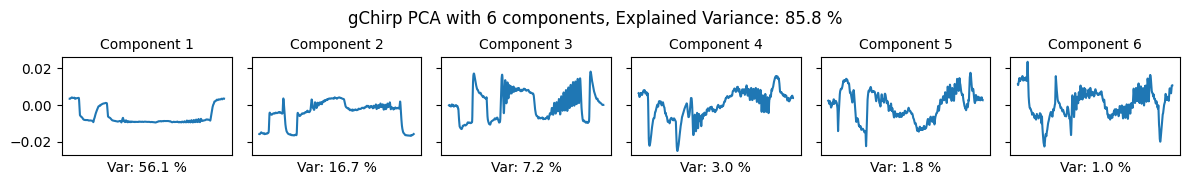

In [67]:
fig, axs = plt.subplots(1, 6, figsize=(12, 2), sharey=True)

fig.suptitle(
    f"gChirp PCA with 6 components, "
    f"Explained Variance: {sum(np.round(components_pca.explained_variance_ratio_ * 100, 1))} %",
    y=0.9
)

for i in range(n_components):
    axs[i].plot(components_pca.components_[i])
    axs[i].set_title(f"Component {i+1}", fontsize=10)
    axs[i].set_xticks([])
    axs[i].set_xlabel(
        f"Var: {np.round(components_pca.explained_variance_ratio_[i] * 100, 1)} %"
    )

plt.tight_layout()
plt.savefig(f"../plots/clustering/PCA_components_gChirp.png")
plt.show()

In [74]:
df_pca_gchirp = pd.DataFrame(
    pca_gchirp,
    columns=[f"PC{i+1}" for i in range(pca_gchirp.shape[1])]
)
df_pca_gchirp.head()

,PC1,PC2,PC3,PC4,PC5,PC6
0,-9.737835,-21.285170,-33.306186,56.451836,54.544355,17.348130
1,25.949071,-32.818090,-32.333061,69.273274,79.308822,28.439713
2,72.060035,71.768363,-49.237883,60.627500,48.920094,14.410864
3,92.002993,44.582332,-31.698427,65.262891,71.434653,18.238999
4,-12.538580,-0.107221,-27.286343,74.482528,55.069054,15.833843


### GMM

In [128]:
n_components_gmm = 8

gmm = GaussianMixture(n_components = n_components_gmm)
gmm.fit(pca_gchirp)

GaussianMixture(n_components=8)

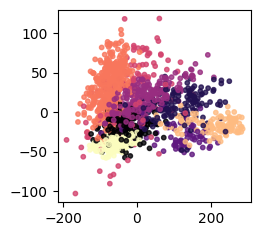

In [132]:
plt.figure(figsize=(2.5,2.5))
plt.scatter(df_pca_gchirp["PC1"], df_pca_gchirp["PC3"],
            c = GaussianMixture(n_components = n_components_gmm).fit_predict(pca_gchirp), cmap="magma", alpha = 0.8, s=10)
plt.show()

### BIC for number of clusters

In [112]:
# Function to calculate BIC for different number of clusters
def calculate_bic_for_gmm(X, max_clusters):
    bic_values = []
    for n in range(1, max_clusters + 1):
        gmm = GaussianMixture(n_components=n, random_state=0).fit(X)
        bic_values.append(gmm.bic(X))
    return bic_values

In [125]:
bic_values = calculate_bic_for_gmm(pca_gchirp, max_clusters=30)
bic_values = np.array(bic_values)

In [126]:
bic_norm = bic_values/bic_values.min()

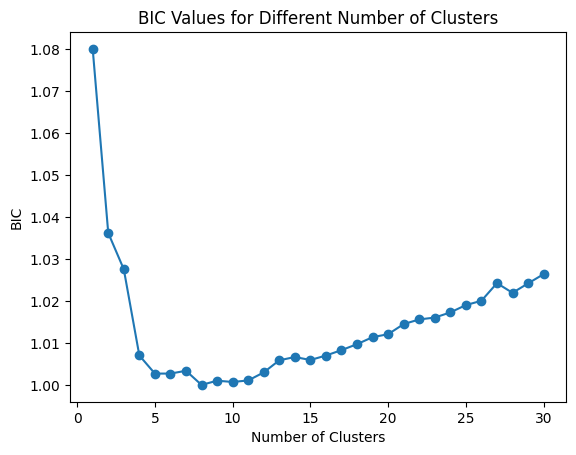

Optimal number of clusters according to BIC: 8


In [127]:
# Plot BIC values
plt.plot(range(1, 31), bic_norm, marker='o')
plt.title('BIC Values for Different Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('BIC')
plt.show()

# Determine the optimal number of clusters
optimal_clusters = np.argmin(bic_norm) + 1
print(f'Optimal number of clusters according to BIC: {optimal_clusters}')

In [70]:
# Visualizing the clustering 
plt.scatter(X_principal['P1'], X_principal['P2'],  
            
plt.show() 

NameError: name 'X_principal' is not defined

In [62]:
components_pca.explained_variance_ratio_

array([0.56142714, 0.167206  , 0.0718592 , 0.0301529 , 0.01814032,
       0.01018506])

In [66]:
pca_gchirp[3]

array([ 92.00299331,  44.58233186, -31.69842682,  65.26289062,
        71.43465322,  18.2389993 ])

In [13]:
pca_gchirp.shape

(1537, 6)

In [67]:
pca_gchirp.fit(average_traces_chirp)

AttributeError: 'numpy.ndarray' object has no attribute 'fit'

In [14]:
components_pca.components_.shape

(6, 16516)

 ...]

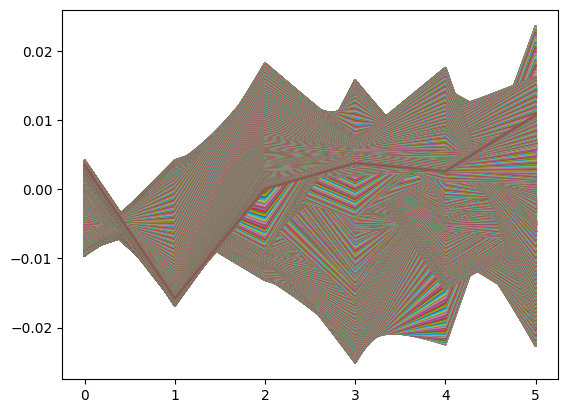

In [61]:
plt.plot(components_pca.components_)

In [56]:
sum(components_pca.explained_variance_ratio_)

0.8589706105491827

In [25]:
fps = 500  # frames per second, same as used later for the scale bar

start_time = 3.0  # seconds, start of on-step

def get_onstep_mean(row):
    trigs = np.asarray(row["triggertimes_rel_gChirp"])
    end_time = trigs[1]  # second trigger = end of on-step (~4.9972s)
    
    trace = np.asarray(row["average_norm_gChirp"])
    start_frame = int(round(start_time * fps))
    end_frame = int(round(end_time * fps))
    
    window = trace[start_frame:end_frame]
    return np.nanmean(window)

# Compute mean response in the on-step window for every ROI
onstep_means = df_c1_thresh.apply(get_onstep_mean, axis=1).values

# Sort descending (max -> min). NaNs (if any) get pushed to the bottom.
means_filled = np.where(np.isnan(onstep_means), -np.inf, onstep_means)
sort_idx = np.argsort(-means_filled)

# Apply the sort to the traces used for the heatmap
average_traces_chirp_sorted = average_traces_chirp[sort_idx]

print("Sorted", len(sort_idx), "ROIs by on-step mean (max to min).")

Sorted 1537 ROIs by on-step mean (max to min).


In [26]:
# --- Add time scale bar ---
seconds_chirp = 5
bar_length_chirp = fps * seconds_chirp  # 2500 frames

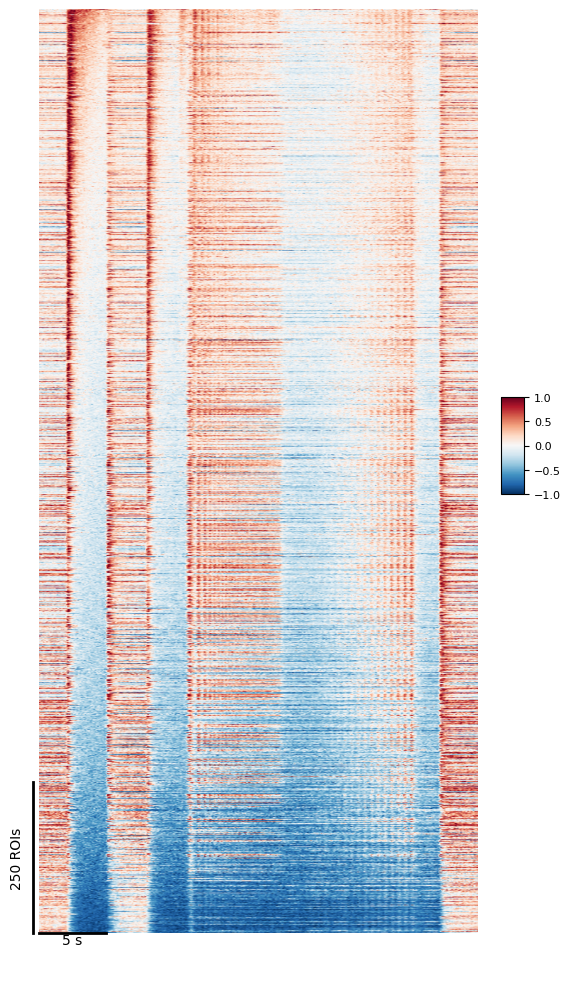

In [27]:
fig, ax = plt.subplots(figsize=(6, 10))
im = ax.imshow(average_traces_chirp_sorted, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
ax.axis("off")

# --- horizontal time scale bar (your existing code) ---
x_start = 0
y_pos = ax.get_ylim()[0] + 0.5  # just below the plot
ax.plot([x_start, x_start + bar_length_chirp], [y_pos, y_pos], color='black', lw=2, clip_on=False)
ax.text(x_start + bar_length_chirp / 2, y_pos + 0.75, #* (ax.get_ylim()[1] - ax.get_ylim()[0]),
        f'{seconds_chirp} s', ha='center', va='top', fontsize=10, color="black")

# --- vertical ROI count scale bar (flush against left edge, starting at row 0) ---
n_rois_bar = 250
x_lim = ax.get_xlim()
y_lim = ax.get_ylim()  # (nrows - 0.5, -0.5) since origin='upper' by default
x_bar = x_lim[0] - 250  # flush with the left edge of the image, no indentation
y_top_of_bar = y_lim[1] + average_traces_chirp.shape[0] - n_rois_bar     # top of the image = top of row 0 (y = -0.5)
y_bottom_of_bar = y_top_of_bar + n_rois_bar  # extends down n_rois_bar rows
ax.plot([x_bar, x_bar], [y_top_of_bar, y_bottom_of_bar],
        color='black', lw=2, clip_on=False)
ax.text(x_bar - 0.02 * (x_lim[1] - x_lim[0]), (y_top_of_bar + y_bottom_of_bar) / 2,
        f'{n_rois_bar} ROIs', ha='right', va='center', rotation=90, fontsize=10, color="black")

# --- colorbar on the right, only 10% of the plot's height ---
# bbox_to_anchor: (x0, y0, width, height) in axes-fraction coordinates
cax = ax.inset_axes([1.05, 0.5, 0.05, 0.1])  # x0=1.05 (just right of ax), y0=0.45 (vertically centered), width=5%, height=10%
cbar = fig.colorbar(im, cax=cax)
cbar.ax.tick_params(labelsize=8)

plt.tight_layout()

In [28]:
len(df_c1[df_c1["qidx_lChirp"] > 0.35])

796

In [29]:
len(df_c1)

2944

In [32]:
len(df_c1_thresh[df_c1_thresh["qidx_lChirp"] > 0.35])

473